In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
# We use sklearn's built-in selector instead of mlxtend to avoid errors
from sklearn.feature_selection import SequentialFeatureSelector

In [2]:
Df = pd.read_csv('AB_NYC_2019.csv')

In [3]:
print(f"Original Data Shape: {Df.shape}")

Original Data Shape: (48895, 16)


In [4]:
ColsToDrop = ["id", "host_id", "name", "host_name", "last_review", "price"]
X = Df.drop(columns=ColsToDrop, errors='ignore')
Y = Df["price"]

In [5]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [6]:
NumericCols = Xtrain.select_dtypes(include=np.number).columns.tolist()
CategoricalCols = Xtrain.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric Features: {NumericCols}")
print(f"Categorical Features: {CategoricalCols}")

Numeric Features: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical Features: ['neighbourhood_group', 'neighbourhood', 'room_type']


In [7]:
ImpNum = SimpleImputer(strategy='median')
Xtrain[NumericCols] = ImpNum.fit_transform(Xtrain[NumericCols])
Xtest[NumericCols] = ImpNum.transform(Xtest[NumericCols])

ImpCat = SimpleImputer(strategy='most_frequent')
Xtrain[CategoricalCols] = ImpCat.fit_transform(Xtrain[CategoricalCols])
Xtest[CategoricalCols] = ImpCat.transform(Xtest[CategoricalCols])

XtrainEncoded = pd.get_dummies(Xtrain, columns=CategoricalCols, drop_first=True)
XtestEncoded = pd.get_dummies(Xtest, columns=CategoricalCols, drop_first=True)

XtrainEncoded, XtestEncoded = XtrainEncoded.align(XtestEncoded, join='left', axis=1, fill_value=0)

Scaler = StandardScaler()
XtrainPrepared = pd.DataFrame(Scaler.fit_transform(XtrainEncoded), columns=XtrainEncoded.columns)
XtestPrepared = pd.DataFrame(Scaler.transform(XtestEncoded), columns=XtestEncoded.columns)

print(f"Processed Data Shape: {XtrainPrepared.shape}")

Processed Data Shape: (39116, 232)


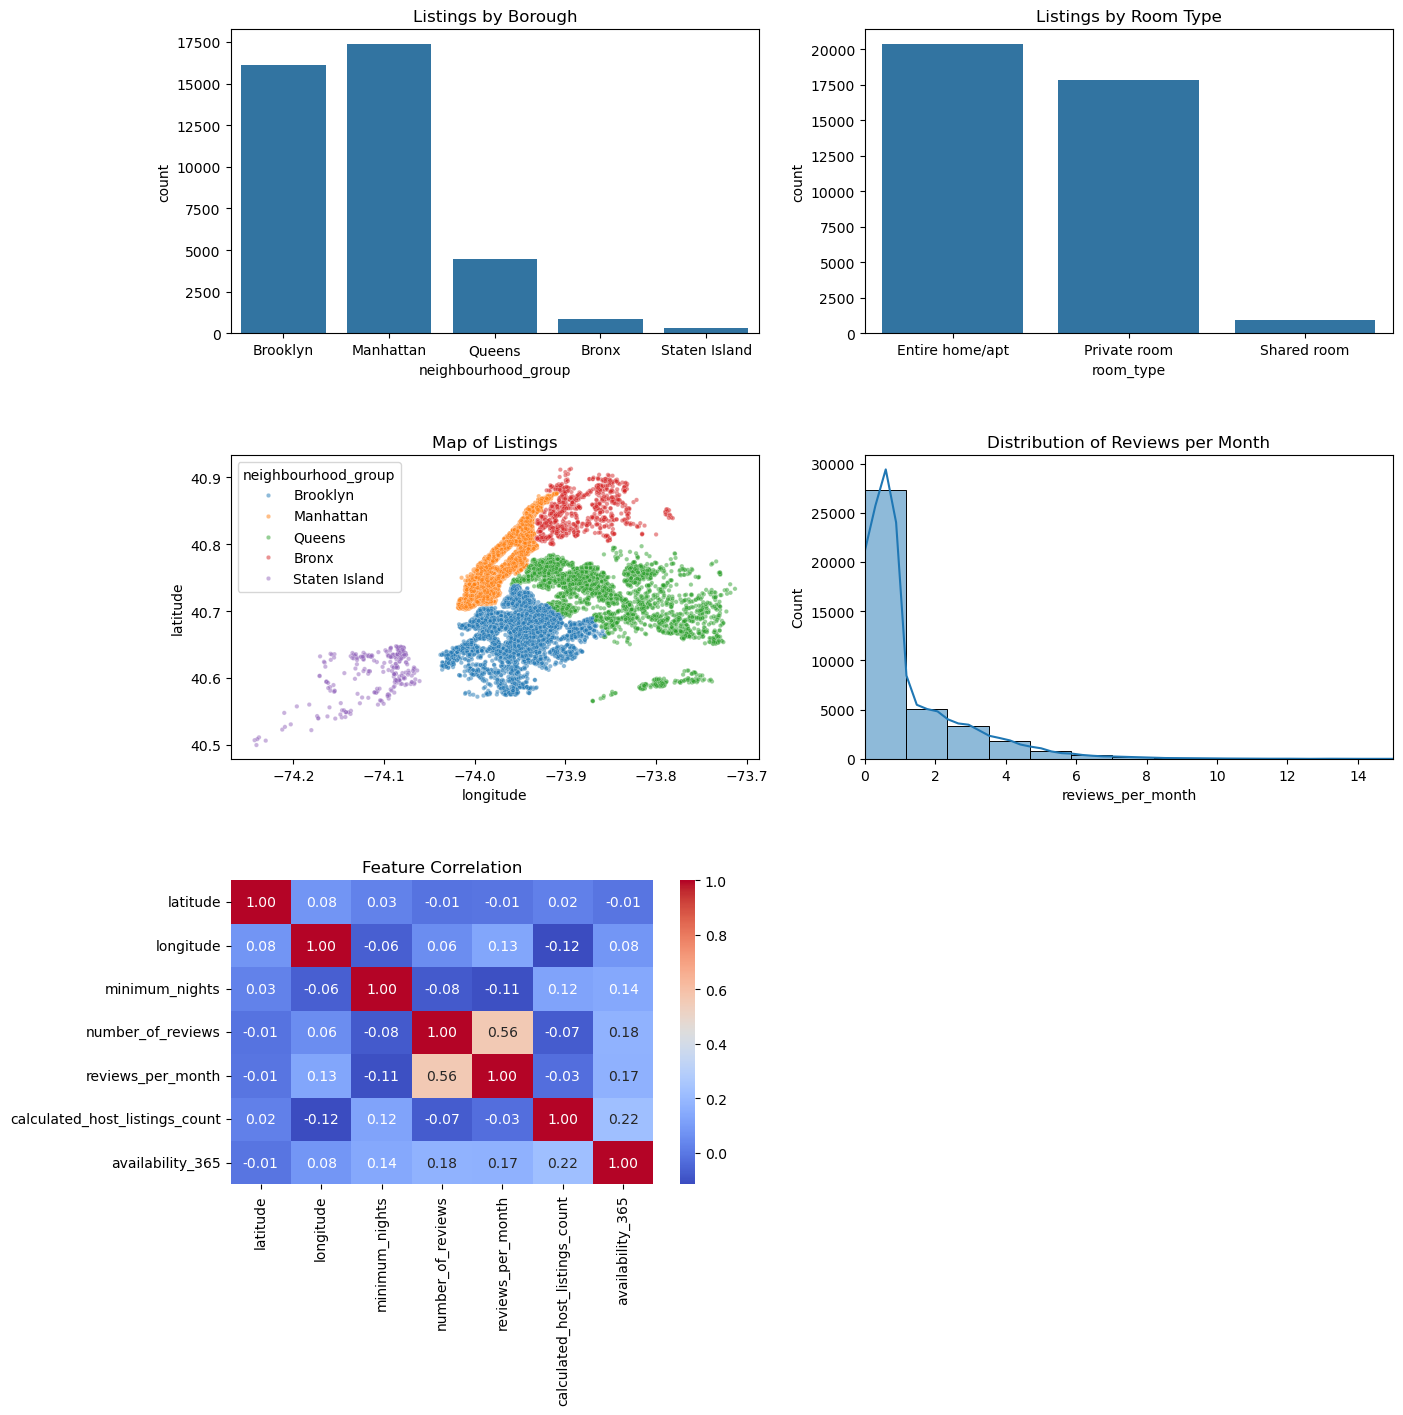

In [8]:
fig, Axes = plt.subplots(3, 2, figsize=(15,15))
plt.subplots_adjust(hspace=0.4)

sns.countplot(data=Xtrain, x="neighbourhood_group", ax=Axes[0,0])
Axes[0,0].set_title("Listings by Borough")

sns.countplot(data=Xtrain, x="room_type", ax=Axes[0,1])
Axes[0,1].set_title("Listings by Room Type")

sns.scatterplot(data=Xtrain, x="longitude", y="latitude", hue="neighbourhood_group", s=10, alpha=0.5, ax=Axes[1,0])
Axes[1,0].set_title("Map of Listings")

sns.histplot(data=Xtrain, x="reviews_per_month", bins=50, kde=True, ax=Axes[1,1])
Axes[1,1].set_title("Distribution of Reviews per Month")
Axes[1,1].set_xlim(0,15)

NumericData = Xtrain.select_dtypes(include=[np.number])
sns.heatmap(NumericData.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=Axes[2,0])
Axes[2,0].set_title("Feature Correlation")

Axes[2,1].axis("off")
plt.show()



--- Tuning Decision Tree ---


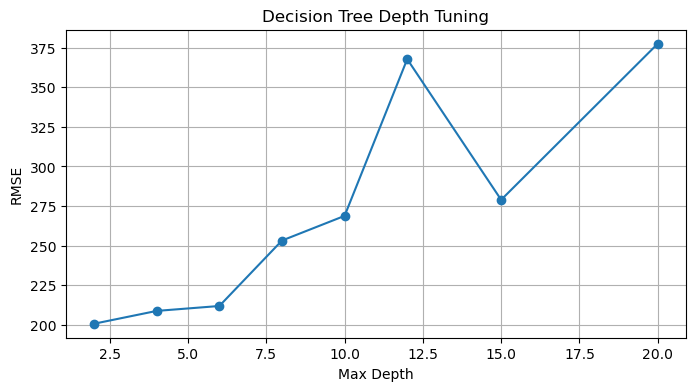

Best Tree Depth: 2 (RMSE: 200.7595)


In [9]:
print("\n--- Tuning Decision Tree ---")
DepthRange = [2,4,6,8,10,12,15,20]
RmseScoresTree = []

for Depth in DepthRange:
    ModelTreeTune = DecisionTreeRegressor(max_depth=Depth, random_state=42)
    ModelTreeTune.fit(XtrainPrepared, Ytrain)
    YpredTreeTune = ModelTreeTune.predict(XtestPrepared)
    Rmse = np.sqrt(mean_squared_error(Ytest, YpredTreeTune))
    RmseScoresTree.append(Rmse)

plt.figure(figsize=(8,4))
plt.plot(DepthRange, RmseScoresTree, marker="o")
plt.title("Decision Tree Depth Tuning")
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

BestDepthIndex = int(np.argmin(RmseScoresTree))
BestDepth = DepthRange[BestDepthIndex]
BestTreeModel = DecisionTreeRegressor(max_depth=BestDepth, random_state=42)
BestTreeModel.fit(XtrainPrepared, Ytrain)
print(f"Best Tree Depth: {BestDepth} (RMSE: {min(RmseScoresTree):.4f})")

In [10]:
print("\n--- Training Linear Regression ---")
LinModel = LinearRegression()
LinModel.fit(XtrainPrepared, Ytrain)


--- Training Linear Regression ---


LinearRegression()


--- Tuning KNN (This may take a minute) ---


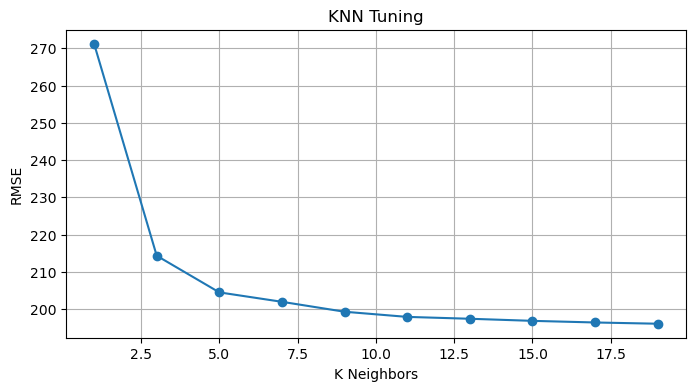

Best KNN K: 19 (RMSE: 196.1191)


In [11]:
print("\n--- Tuning KNN (This may take a minute) ---")

KRange = range(1, 21, 2) 
RmseScoresKnn = []

for K in KRange:
    ModelKnnTune = KNeighborsRegressor(n_neighbors=K, n_jobs=-1)
    ModelKnnTune.fit(XtrainPrepared, Ytrain)
    YpredKnnTune = ModelKnnTune.predict(XtestPrepared)
    Rmse = np.sqrt(mean_squared_error(Ytest, YpredKnnTune))
    RmseScoresKnn.append(Rmse)

plt.figure(figsize=(8,4))
plt.plot(list(KRange), RmseScoresKnn, marker="o")
plt.title("KNN Tuning")
plt.xlabel("K Neighbors")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

BestKIndex = int(np.argmin(RmseScoresKnn))
BestK = list(KRange)[BestKIndex]
BestKnnModel = KNeighborsRegressor(n_neighbors=BestK, n_jobs=-1)
BestKnnModel.fit(XtrainPrepared, Ytrain)
print(f"Best KNN K: {BestK} (RMSE: {min(RmseScoresKnn):.4f})")

Generating curve for: Linear Regression...


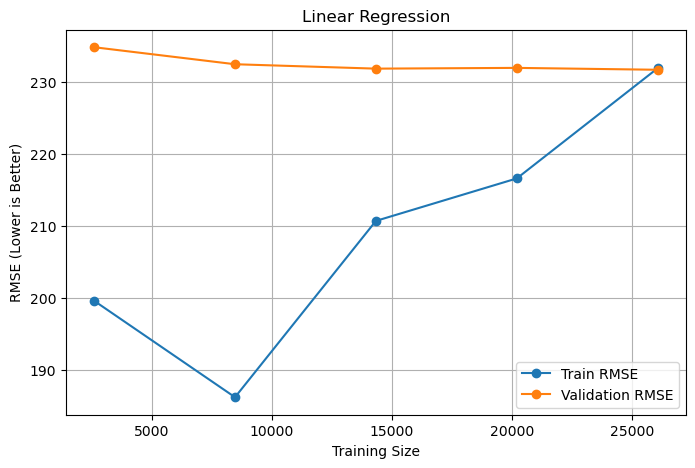

Generating curve for: Decision Tree (Best Depth)...


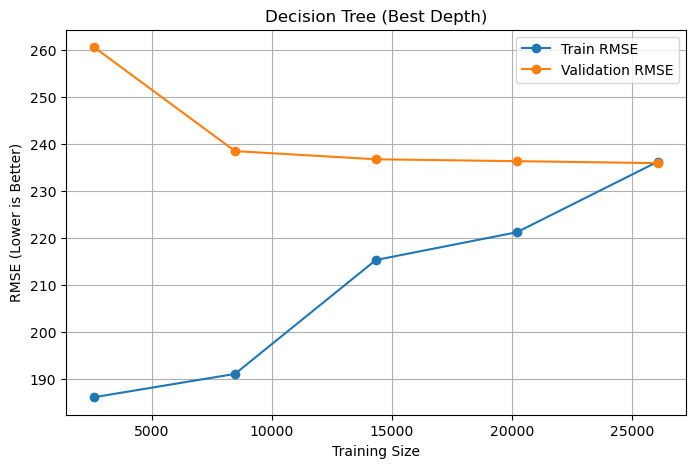

In [13]:
def plotLearningCurves(Estimator, Title, Xdata, Ydata):
    print(f"Generating curve for: {Title}...")
    plt.figure(figsize=(8,5))
    plt.title(Title)
    plt.xlabel("Training Size")
    plt.ylabel("RMSE (Lower is Better)")
    plt.grid(True)
    
    TrainSizes, TrainScores, TestScores = learning_curve(
        Estimator, Xdata, Ydata, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_root_mean_squared_error'
    )
    
    
    TrainMean = -np.mean(TrainScores, axis=1)
    TestMean = -np.mean(TestScores, axis=1)
    
    plt.plot(TrainSizes, TrainMean, "o-", label="Train RMSE")
    plt.plot(TrainSizes, TestMean, "o-", label="Validation RMSE")
    plt.legend()
    plt.show()


plotLearningCurves(LinModel, "Linear Regression", XtrainPrepared, Ytrain)
plotLearningCurves(BestTreeModel, "Decision Tree (Best Depth)", XtrainPrepared, Ytrain)

In [14]:
Models = [
    ("Linear Regression", LinModel),
    ("KNN (Best K)", BestKnnModel),
    ("Decision Tree (Best Depth)", BestTreeModel)
]

Results = []

for Name, Model in Models:
    Ypred = Model.predict(XtestPrepared)
    Mse = mean_squared_error(Ytest, Ypred)
    Rmse = np.sqrt(Mse)
    R2 = r2_score(Ytest, Ypred)
    Results.append([Name, Rmse, Mse, R2])

ResultsDf = pd.DataFrame(Results, columns=["Model","RMSE","MSE","R2"])
print("\nFinal Model Comparison:")
print(ResultsDf)


Final Model Comparison:
                        Model        RMSE           MSE        R2
0           Linear Regression  195.480932  38212.794743  0.136204
1                KNN (Best K)  196.119109  38462.704960  0.130555
2  Decision Tree (Best Depth)  200.759509  40304.380602  0.088924
